# WELCOME TO V768 - Measuring Vision with Psychophysics

### Lab 1 - Classical Methods
This lab covers the three classical psychophysics methods: (A) the method of limits, (B) the method of adjustment, and (C) the method of constant stimuli. For this lab, you will collect data using PsychoPy and analyze the data you generate.

### Learning Outcomes
##### (i.e., what you will be able to do at the end of this lab)
1. Describe each of the three classical psychophysical methods.
2. Identify the strengths and weaknesses of each method.

### Questions
- A. Method of Limits
    - How does the method of limits work? You can use this experiment as an exmple to explain. 
    - Write a figure caption for the three panels in Figure 1.
    - What are the potential weaknesses of the method of limits? (These can include practical problems with data collection.)
- B. Method of Adjustment
    - How does the method of adjustment work?
    - Write a figure caption for the three panels in Figure 2. 
    - What are the potential weaknesses of the method of adjustment?
- C. Method of Constant Stimuli
    - How does the method of constant stimuli work? 
    - Write a figure caption for the two panels in Figure 3 and for Figure 4. 
    - What are the potential weaknesses of the method of constant stimuli?
- D. Wrap-Up
    - Are these three experiments measuring the same thing? Explain the similarities and differences. Can you change the experiments so that they do measure the same thing?

## Part A. Method of Limits
### Step 1. Data collection
To collect data, open the PsychoPy ".psyexp" file in the folder titled ***"method-of-limits"***, and run that experiment. The instructions will appear on the screen before the trials begin. The experiment includes 10 trials.

Run this code cell below to ensure you have the proper modules and submodules for the analysis

In [133]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Step 2. Load your data
PsychoPy will save your experiment data to a "data" folder (inside of the same folder as the ".psyexp" file). The filename will start with the subject ID you used and end with the date/time of data collection.

Change the `subject_saved` variable to the participant number/name that you have set for your experiment in the code segment below

In [134]:
data_dir = Path.cwd() / "method-of-limits" / "data"

subject_saved = "demo" # Change this to the subject number or name you want to analyze

subject_pattern = re.compile(rf"^{subject_saved}_")

matches = [f for f in data_dir.iterdir() if f.is_file() and f.suffix == '.csv' and subject_pattern.match(f.name)]

df = pd.read_csv(matches[0])
df.head()

,direction,thisN,thisTrialN,thisRepN,trials.thisRepN,trials.thisTrialN,trials.thisN,trials.thisIndex,thisRow.t,notes,...,trial.stopped,response,participant,session,date,expName,psychopyVersion,frameRate,expStart,Unnamed: 26
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,demo,1,2025-01-06_16h24.27.517,method-of-limits,2024.2.4,NaN,2025-01-06 16h24.32.789191 -0500,NaN
1,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.933461,NaN,...,6.992229,0.065393,demo,1,2025-01-06_16h24.27.517,method-of-limits,2024.2.4,NaN,2025-01-06 16h24.32.789191 -0500,NaN
2,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,7.002535,NaN,...,10.454882,0.007993,demo,1,2025-01-06_16h24.27.517,method-of-limits,2024.2.4,NaN,2025-01-06 16h24.32.789191 -0500,NaN
3,-1.0,2.0,0.0,1.0,1.0,0.0,2.0,1.0,10.462329,NaN,...,14.838388,0.047938,demo,1,2025-01-06_16h24.27.517,method-of-limits,2024.2.4,NaN,2025-01-06 16h24.32.789191 -0500,NaN
4,1.0,3.0,1.0,1.0,1.0,1.0,3.0,0.0,14.852594,NaN,...,18.438191,0.002571,demo,1,2025-01-06_16h24.27.517,method-of-limits,2024.2.4,NaN,2025-01-06 16h24.32.789191 -0500,NaN


In [135]:
# The first row of the CSV file contains the column names, so we can drop it and reset the index.
df = df.iloc[1:].reset_index(drop=True)

# These columns are not needed for our analysis, so we can drop them.
remove = ['notes', 'instructions.started', 'instructions.stopped']
df = df.drop(columns=remove)

### Step 3. Analyze your data

For this experiment, the stimulus was a sinusoidal grating with a Gaussian mask. The grayscale luminance range in PsychoPy is -1 to 1, where -1 is black, 1 is white, and 0 is middle gray. The background luminance was set to 0. Thus, if the stimulus contrast were 0, the grating would be middle gray (the same luminance as the background), and if the stimulus contrast were 1, the grating's luminance would range from black to white.

PsychoPy saved the stimulus contrast at the time of response. For trials that started with a low stimulus contrast, this is the contrast when the participant reported that the stimulus appeared. For trials that started with a high stimulus contrast, this is the contrast when the participant reported that the stimulus disappeared.

In [136]:
trials = list(range(2, len(df) + 2))

# Extracting the stimiulus's initial contrast level; either going to be high (1) or low (-1).
stimulus_start = df['direction']

# Extract the response data
contrast_response = df['response']


#### Visualize the response per trial

TODO:
look into the fig, ax structure of matplotlib to make sure that I can plot the all the figures on the same plot space
but we do want to build on the initial plots that we have generated for the figures that might contain multiple plots

In [137]:
print(stimulus_start)
print(len(stimulus_start))
print((stimulus_start == -1).sum())
print((stimulus_start == 1).sum())
print(trials)

0   -1.0
1    1.0
2   -1.0
3    1.0
4   -1.0
5    1.0
6   -1.0
7    1.0
8   -1.0
9    1.0
Name: direction, dtype: float64
10
5
5
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


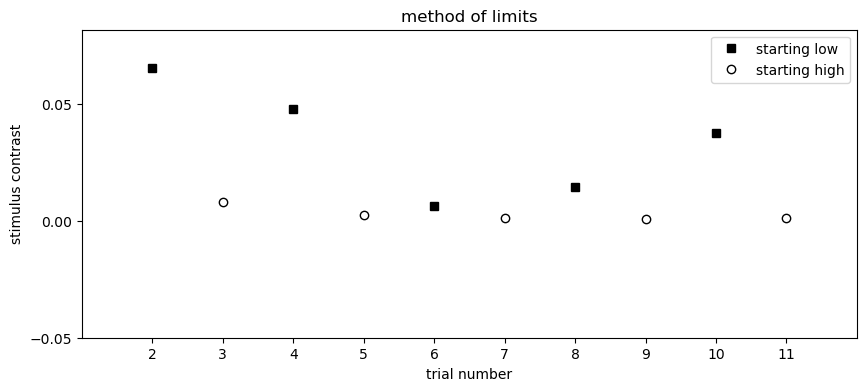

In [138]:
def plot_method_of_limits(ax):
    
    ax.plot(
        pd.Series(trials)[stimulus_start == -1],
        contrast_response[stimulus_start == -1],
        'ks',
        markerfacecolor='k',
        label="starting low"
    )

    ax.plot(
        pd.Series(trials)[stimulus_start == 1],
        contrast_response[stimulus_start == 1],
        'ko',
        markerfacecolor='none',
        label="starting high"
    )

    ax.legend()
    ax.set_xlabel("trial number")
    ax.set_xticks(np.arange(2, 12))
    ax.set_yticks(np.arange(-0.05, 0.1, 0.05))
    ax.set_ylabel("stimulus contrast")
    ax.set_xlim([1, 12])
    ax.set_ylim([-0.05, 1.25 * contrast_response.max()])
    ax.set_title("method of limits")

fig, ax = plt.subplots(figsize=(10, 4))
plot_method_of_limits(ax)

#### Plot the average reported contrast, separated by direction of change

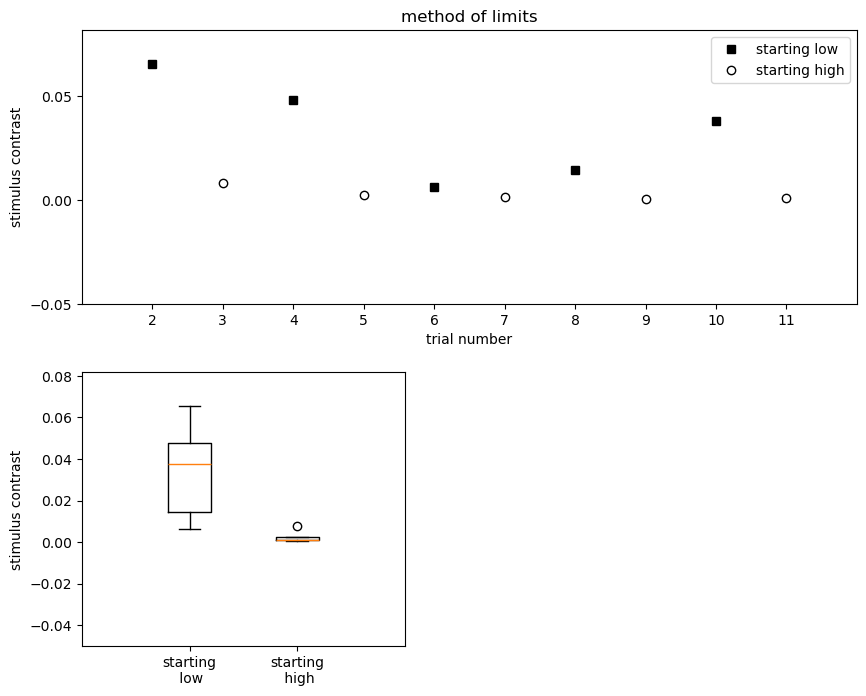

In [139]:
def plot_method_of_limits_boxplot(ax):
    ax.boxplot(
        [
            contrast_response[stimulus_start == -1],
            contrast_response[stimulus_start == 1]
        ],
        positions=[1, 2],
        widths=0.4
    )

    ax.set_xlim(0, 3)
    ax.set_ylim(-0.05, 1.25 * contrast_response.max())
    ax.set_ylabel('stimulus contrast')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["starting\n low", "starting\n high"])


# Create figure and axes explicitly
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2)

plot_method_of_limits(fig.add_subplot(gs[0, :]))
plot_method_of_limits_boxplot(fig.add_subplot(gs[1, 0]))

fig.subplots_adjust(hspace=0.25, wspace=0.4)

#### Plotting the overall average reported contrast

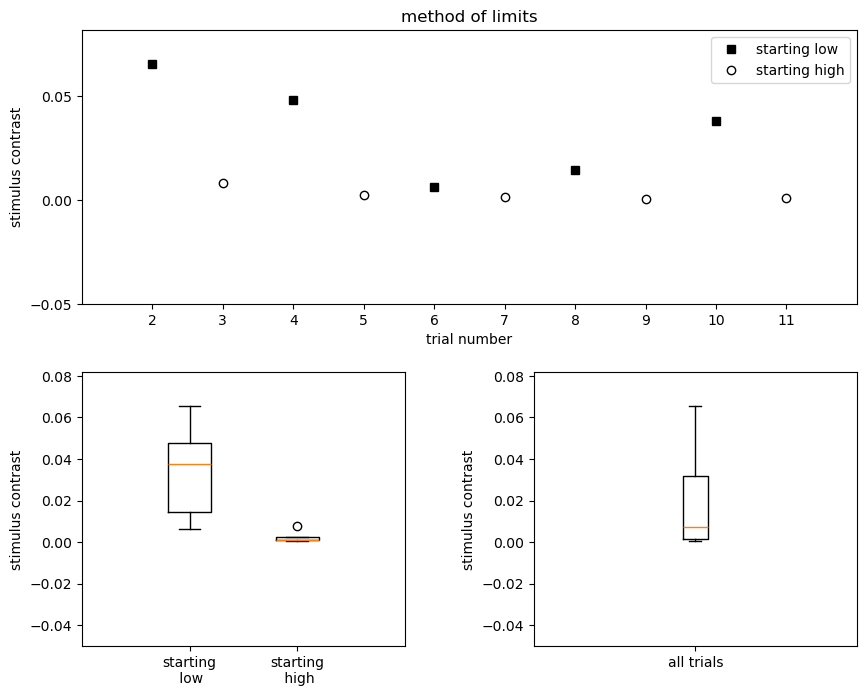

In [140]:
def plot_all_mol_trials_boxplot(ax):
    ax.boxplot([contrast_response])
    ax.set_xlim(0, 2)
    ax.set_ylim(-0.05, 1.25 * contrast_response.max())
    ax.set_ylabel('stimulus contrast')
    ax.set_xticks([1])
    ax.set_xticklabels(["all trials"])


# Create figure and axes explicitly
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2)

plot_method_of_limits(fig.add_subplot(gs[0, :]))
plot_method_of_limits_boxplot(fig.add_subplot(gs[1, 0]))
plot_all_mol_trials_boxplot(fig.add_subplot(gs[1, 1]))

fig.subplots_adjust(hspace=0.25, wspace=0.4)

## Part B. Method of Adjustment
### Step 1. Data Collection
To collect data, open the PsychoPy ".psyexp" file in the folder titled "method-of-adjustment", and run that experiment. The instructions will appear on the screen before the trials begin. The experiment includes 20 trials.

### Step 2. Load your data
Just like ***Part A. Method of Limits***, change the `subject_saved` variable to the participant number/name that you have set for your experiment in the code segment below

In [141]:
data_dir = Path.cwd() / "method-of-adjustment" / "data"

subject_saved = "demo" # Change this to the subject number or name you want to analyze

subject_pattern = re.compile(rf"^{subject_saved}_")

matches = [f for f in data_dir.iterdir() if f.is_file() and f.suffix == '.csv' and subject_pattern.match(f.name)]

df_moa = pd.read_csv(matches[0])
df_moa.head()

,direction,control,thisN,thisTrialN,thisRepN,trials.thisRepN,trials.thisTrialN,trials.thisN,trials.thisIndex,thisRow.t,...,trial.stopped,contrast_response,contrast_target,participant,session,date,expName,psychopyVersion,frameRate,expStart
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,demo,1,2025-01-06_16h30.16.790,method-of-adjustment,2024.2.4,NaN,2025-01-06 16h30.21.655789 -0500
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.720684,...,8.442215,0.463551,0.367879,demo,1,2025-01-06_16h30.16.790,method-of-adjustment,2024.2.4,NaN,2025-01-06 16h30.21.655789 -0500
2,-1.0,-1.0,1.0,1.0,0.0,0.0,1.0,1.0,3.0,8.460891,...,12.626881,0.374303,0.367879,demo,1,2025-01-06_16h30.16.790,method-of-adjustment,2024.2.4,NaN,2025-01-06 16h30.21.655789 -0500
3,-1.0,1.0,2.0,2.0,0.0,0.0,2.0,2.0,1.0,12.638994,...,17.359671,0.263418,0.367879,demo,1,2025-01-06_16h30.16.790,method-of-adjustment,2024.2.4,NaN,2025-01-06 16h30.21.655789 -0500
4,1.0,-1.0,3.0,3.0,0.0,0.0,3.0,3.0,2.0,17.372374,...,21.956551,0.318026,0.367879,demo,1,2025-01-06_16h30.16.790,method-of-adjustment,2024.2.4,NaN,2025-01-06 16h30.21.655789 -0500


In [142]:
# The first row of the CSV file contains the column names, so we can drop it and reset the index.
df_moa = df_moa.iloc[1:].reset_index(drop=True)

# These columns are not needed for our analysis, so we can drop them.
remove = ['notes', 'instructions.started', 'instructions.stopped']
df_moa = df_moa.drop(columns=remove)

### Step 3. Analyze your data

For this experiment, the stimulus was a sinusoidal grating with a Gaussian mask. The grayscale luminance range in PsychoPy is -1 to 1, where -1 is black, 1 is white, and 0 is middle gray. The background luminance was set to 0. Thus, if the stimulus contrast were 0, the grating would be middle gray (the same luminance as the background), and if the stimulus contrast were 1, the grating's luminance would range from black to white.

PsychoPy saved the stimulus contrast at the time of response. For trials that started with a low stimulus contrast, this is the contrast when the participant reported that the stimulus appeared. For trials that started with a high stimulus contrast, this is the contrast when the participant reported that the stimulus disappeared.

In [143]:
trials = pd.Series(list(range(1, len(df_moa) + 1)))

# Extracting the stimiulus's initial contrast level; either going to be high (1) or low (-1).
control_start = df_moa['control']

# Extract the response data
contrast_target = df_moa['contrast_target']

contrast_response = df_moa['contrast_response']

#### Visualize the response per trial

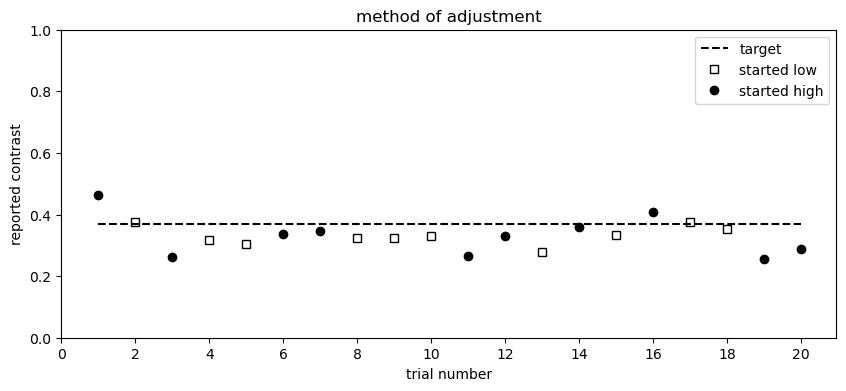

In [144]:
def plot_method_of_adjustment_trial(ax):
    low_ind = control_start == -1
    high_ind = control_start == 1

    # plot the contrast of the target grating
    ax.plot(trials, contrast_target, 'k--')

    # plot the trials that started at low contrast
    ax.plot(trials[low_ind], contrast_response[low_ind], 'ks', markerfacecolor='none')

    # plot the trials that started at high contrast
    ax.plot(trials[high_ind], contrast_response[high_ind], 'ko')

    ax.legend(['target', 'started low', 'started high'])
    ax.set_xlabel('trial number')
    ax.set_ylabel('reported contrast')
    ax.set_ylim([0, 1])
    ax.set_xticks(range(0, 21, 2))
    ax.set_title('method of adjustment')


# Create figure and axes explicitly
fig, ax = plt.subplots(figsize=(10, 4))

plot_method_of_adjustment_trial(ax)

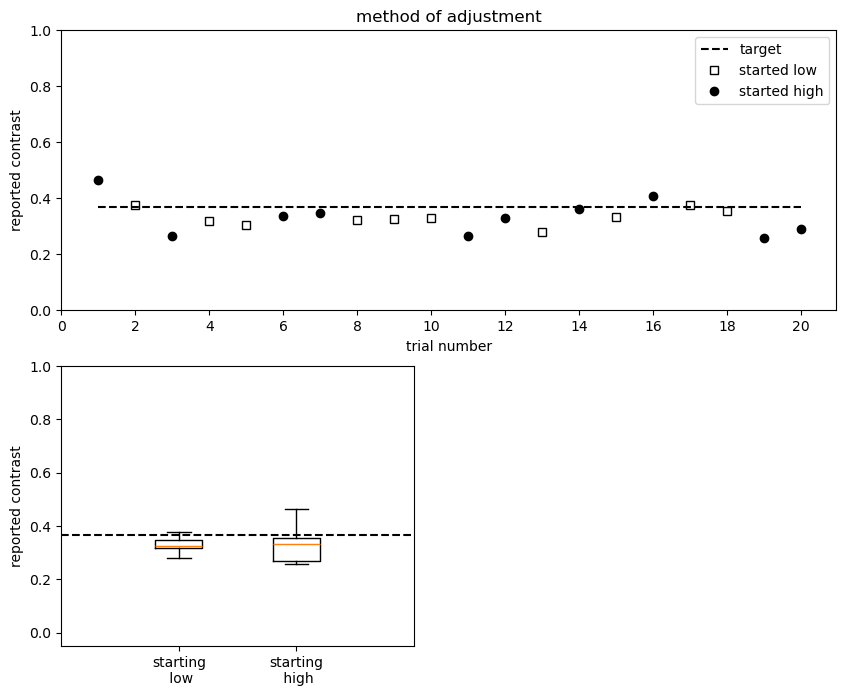

In [145]:
def plot_moa_boxplot_by_direction(ax):
      ax.boxplot(
            [
                  contrast_response[control_start == -1],
            contrast_response[control_start == 1]
            ],
            positions=[1, 2],
            widths=0.4
            )

      ax.set_xlim(0, 3)
      ax.set_ylim(-0.05, 1.00)
      ax.plot([0, 3], [np.mean(contrast_target), np.mean(contrast_target)], 'k--')
      ax.set_ylabel('reported contrast')
      ax.set_xticks([1, 2])
      ax.set_xticklabels(["starting\n low", "starting\n high"])


# Create figure and axes explicitly
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2)

plot_method_of_adjustment_trial(fig.add_subplot(gs[0, :]))
plot_moa_boxplot_by_direction(fig.add_subplot(gs[1, 0]))

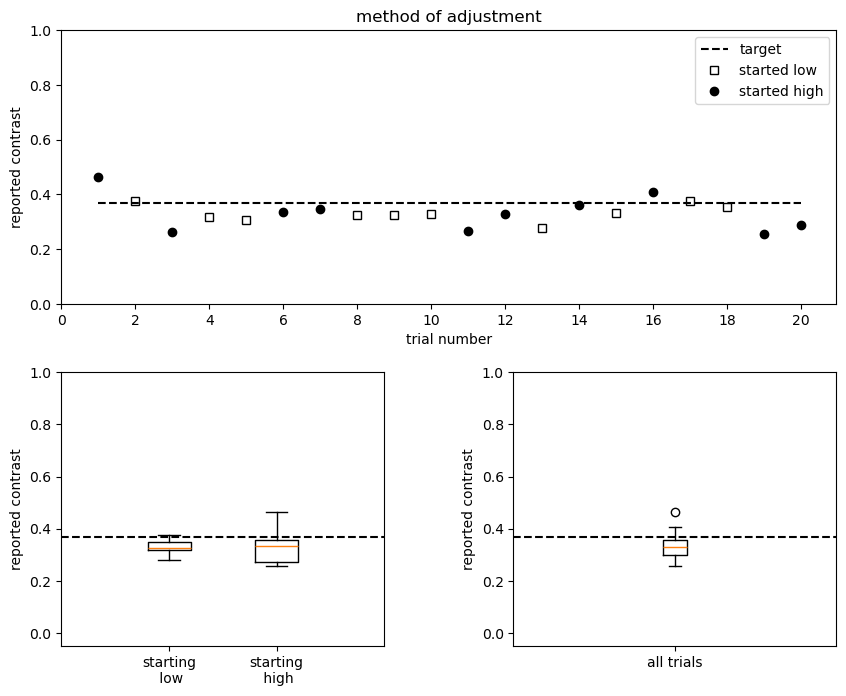

In [147]:
def plot_moa_all_trials_boxplot(ax):
    ax.boxplot([contrast_response])
    ax.set_xticklabels(['all trials'])

    ax.set_ylabel('reported contrast')

    target_mean = np.mean(contrast_target)
    ax.plot([0, 2], [target_mean, target_mean], 'k--', label='target')

    ax.set_xlim([0, 2])
    ax.set_ylim([-0.05, 1.00])


# Create figure and axes explicitly
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2)

plot_method_of_adjustment_trial(fig.add_subplot(gs[0, :]))
plot_moa_boxplot_by_direction(fig.add_subplot(gs[1, 0]))
plot_moa_all_trials_boxplot(fig.add_subplot(gs[1, 1]))

fig.subplots_adjust(hspace=0.25, wspace=0.4)

## Part C. Method of Constant Stimuli
### Step 1. Data collection
To collect data, open the PsychoPy ".psyexp" file in the folder titled ***"method-of-constant-stimuli"***, and run that experiment. The instructions will appear on the screen before the trials begin. The experiment includes 10 trials.

### Step 2. Load your data
Before running this section of code, remember to change the `subject_saved` to the subject name you used to run the experiment

In [149]:
data_dir = Path.cwd() / "method-of-constant-stimuli" / "data"

subject_saved = "demo" # Change this to the subject number or name you want to analyze

subject_pattern = re.compile(rf"^{subject_saved}_")

matches = [f for f in data_dir.iterdir() if f.is_file() and f.suffix == '.csv' and subject_pattern.match(f.name)]

df_mocs = pd.read_csv(matches[0])
df_mocs.head()


,contrast,thisN,thisTrialN,thisRepN,response.keys,response.rt,response.duration,trials.thisRepN,trials.thisTrialN,trials.thisN,...,trials.response.rt,trials.response.duration,participant,session,date,expName,psychopyVersion,frameRate,expStart,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,demo,1,2025-01-16_21h16.39.043,method_of_constant_stimuli,2024.2.4,NaN,2025-01-16 21h16.45.421908 -0500,NaN
1,0.9000,0.0,0.0,0.0,up,0.426800,NaN,0.0,0.0,0.0,...,0.426800,NaN,demo,1,2025-01-16_21h16.39.043,method_of_constant_stimuli,2024.2.4,NaN,2025-01-16 21h16.45.421908 -0500,NaN
2,0.0000,1.0,1.0,0.0,down,1.335804,NaN,0.0,1.0,1.0,...,1.335804,NaN,demo,1,2025-01-16_21h16.39.043,method_of_constant_stimuli,2024.2.4,NaN,2025-01-16 21h16.45.421908 -0500,NaN
3,0.0001,2.0,2.0,0.0,down,0.395193,NaN,0.0,2.0,2.0,...,0.395193,NaN,demo,1,2025-01-16_21h16.39.043,method_of_constant_stimuli,2024.2.4,NaN,2025-01-16 21h16.45.421908 -0500,NaN
4,0.0010,3.0,3.0,0.0,down,0.655127,NaN,0.0,3.0,3.0,...,0.655127,NaN,demo,1,2025-01-16_21h16.39.043,method_of_constant_stimuli,2024.2.4,NaN,2025-01-16 21h16.45.421908 -0500,NaN


In [154]:
# The first row of the CSV file contains the column names, so we can drop it and reset the index.
df_mocs = df_mocs.iloc[1:].reset_index(drop=True)

# These columns are not needed for our analysis, so we can drop them.
remove = ['notes', 'begin_experiment.started', 'begin_experiment.stopped']
df_mocs = df_mocs.drop(columns=remove)

In [161]:
trials = pd.Series(list(range(1, len(df_mocs) + 1)))

stimulus_contrast = df_mocs['contrast']

response_key = df_mocs['response.keys']

response = response_key.apply(lambda x: 1 if x == 'up' else 0)

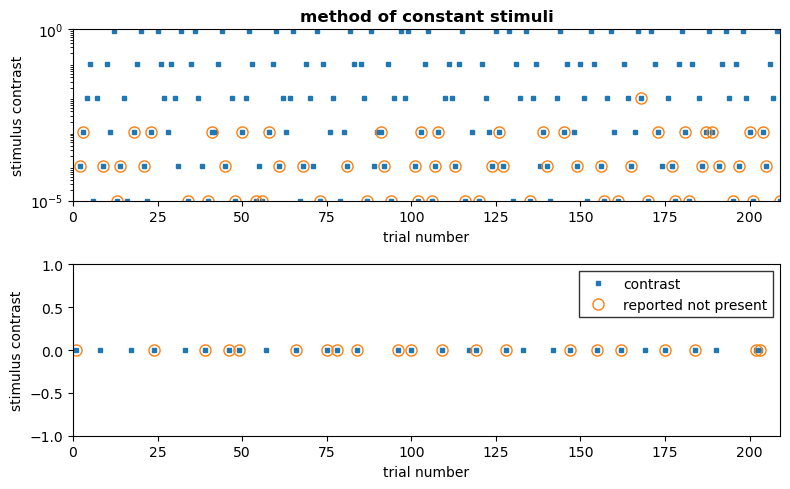

In [167]:
fig = plt.figure(figsize=(8, 5))

# ---------------- Top subplot ----------------
ax1 = fig.add_subplot(211)

# Boolean mask for "reported not present"
chose_down = (response == False)

# All stimulus contrast values: blue square markers
ax1.plot(
    trials,
    stimulus_contrast,
    linestyle='None',
    marker='s',
    markersize=3,
    color='tab:blue',
    label='contrast'
)

# "Reported not present": hollow orange circles
ax1.plot(
    trials[chose_down],
    stimulus_contrast[chose_down],
    linestyle='None',
    marker='o',
    markersize=8,
    markerfacecolor='none',
    markeredgecolor='tab:orange',
    label='reported not present'
)

ax1.set_yscale('log')
ax1.set_xlim(0, len(trials))
ax1.set_ylim(1e-5, 1)
ax1.set_xlabel('trial number')
ax1.set_ylabel('stimulus contrast')
ax1.set_title('method of constant stimuli', fontweight='bold')

ax1.set_yticks([1e-5, 1])
ax1.set_yticklabels([r'$10^{-5}$', r'$10^{0}$'])

# ---------------- Bottom subplot ----------------
ax2 = fig.add_subplot(212)

was_zero = (stimulus_contrast == 0)

# Zero-contrast trials: blue square markers
ax2.plot(
    trials[was_zero],
    stimulus_contrast[was_zero],
    linestyle='None',
    marker='s',
    markersize=3,
    color='tab:blue',
    label='contrast'
)

# Zero-contrast trials where observer reported not present
ind = was_zero & chose_down
ax2.plot(
    trials[ind],
    stimulus_contrast[ind],
    linestyle='None',
    marker='o',
    markersize=8,
    markerfacecolor='none',
    markeredgecolor='tab:orange',
    label='reported not present'
)

ax2.set_xlim(0, len(trials))
ax2.set_ylim(-1, 1)
ax2.set_xlabel('trial number')
ax2.set_ylabel('stimulus contrast')

ax2.legend(
    loc='upper right',
    frameon=True,
    fancybox=False,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

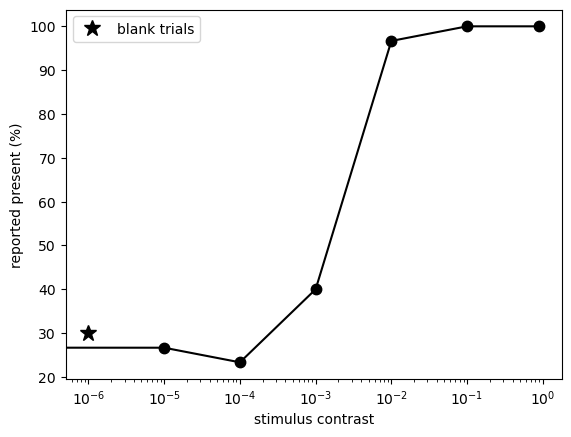

In [171]:
# Create table (like MATLAB table)
mean_responses = pd.DataFrame({
    'response': response,
    'stimulus_contrast': stimulus_contrast
})

# Group by contrast and compute mean response 
contrast_grouped_mean_responses = mean_responses.groupby('stimulus_contrast', as_index=False).mean()
cgmr = contrast_grouped_mean_responses.sort_values('stimulus_contrast')  # important for plotting order

plt.figure()
plt.clf()

# Main psychometric curve
plt.plot(
    cgmr['stimulus_contrast'],
    cgmr['response'] * 100,
    'k.-',
    markersize=15
)

# Scaling for x-axis
plt.xscale('log')

plt.xlabel('stimulus contrast')
plt.ylabel('reported present (%)')

# Add "blank trials" point (zero contrast)
x_blank = cgmr['stimulus_contrast'].iloc[1] / 10
y_blank = cgmr['response'].iloc[0] * 100

plt.plot(
    x_blank,
    y_blank,
    marker='*',            # pentagram
    color='k',
    markersize=12,
    markerfacecolor='k',
    linestyle='None',
    label='blank trials'
)

# Legend (matching MATLAB behavior)
plt.legend(loc='upper left')

plt.show()